Credit Risk Model (using ML) based on data from Kaggle: https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk/data

In [68]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Data Ingestion & Cleaning

In [26]:
df = pd.read_csv(r"C:\Users\Startklar\Documents\Milan\Becoming a quant\Quant Projects - Jan 26 onwards\Credit-Risk-Modeling-with-ML\german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [27]:
df = df.drop(columns="Unnamed: 0")

df=df.dropna().reset_index(drop=True)
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


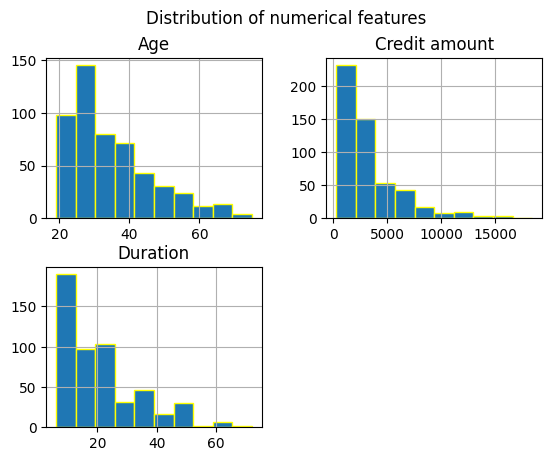

In [28]:
df[["Age", "Credit amount", "Duration"]].hist(bins=10, edgecolor = "yellow")
plt.suptitle("Distribution of numerical features")
plt.show()

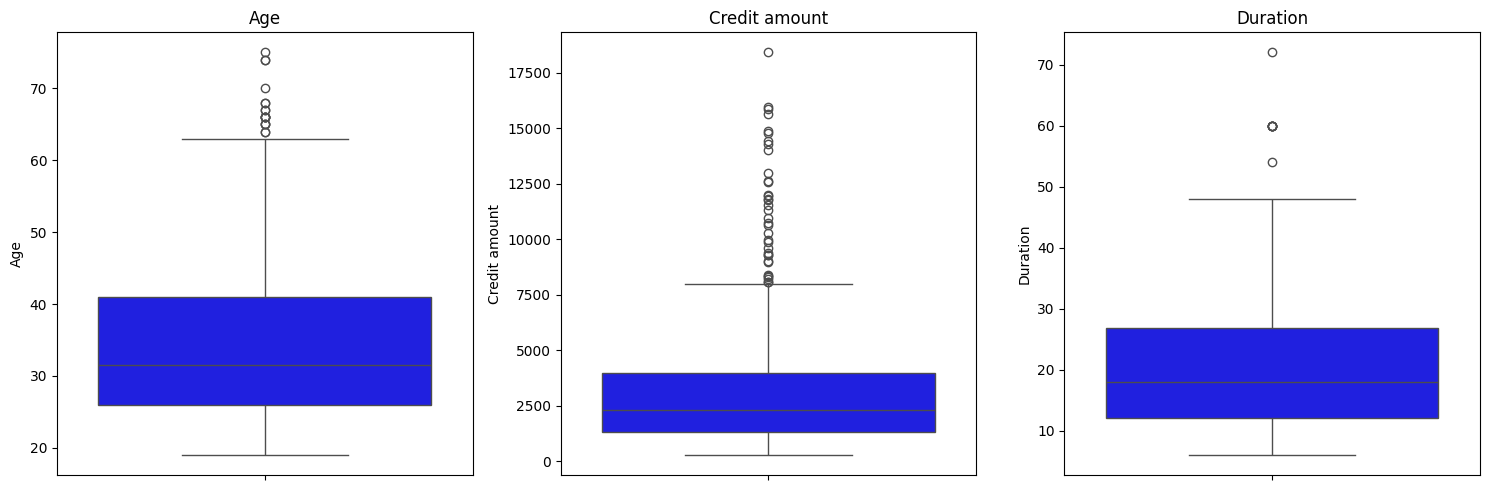

In [32]:
numerical_cols = ["Age", "Credit amount", "Duration"]

plt.figure(figsize=(15,5))
for i, col in enumerate(numerical_cols): 
    plt.subplot(1,3, i+1)
    sns.boxplot(y=df[col], color = "blue")
    plt.title(col)

plt.tight_layout()
plt.show() 

C:\Users\Startklar\AppData\Local\Temp\ipykernel_22484\3262454691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
C:\Users\Startklar\AppData\Local\Temp\ipykernel_22484\3262454691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
C:\Users\Startklar\AppData\Local\Temp\ipykernel_22484\3262454691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value

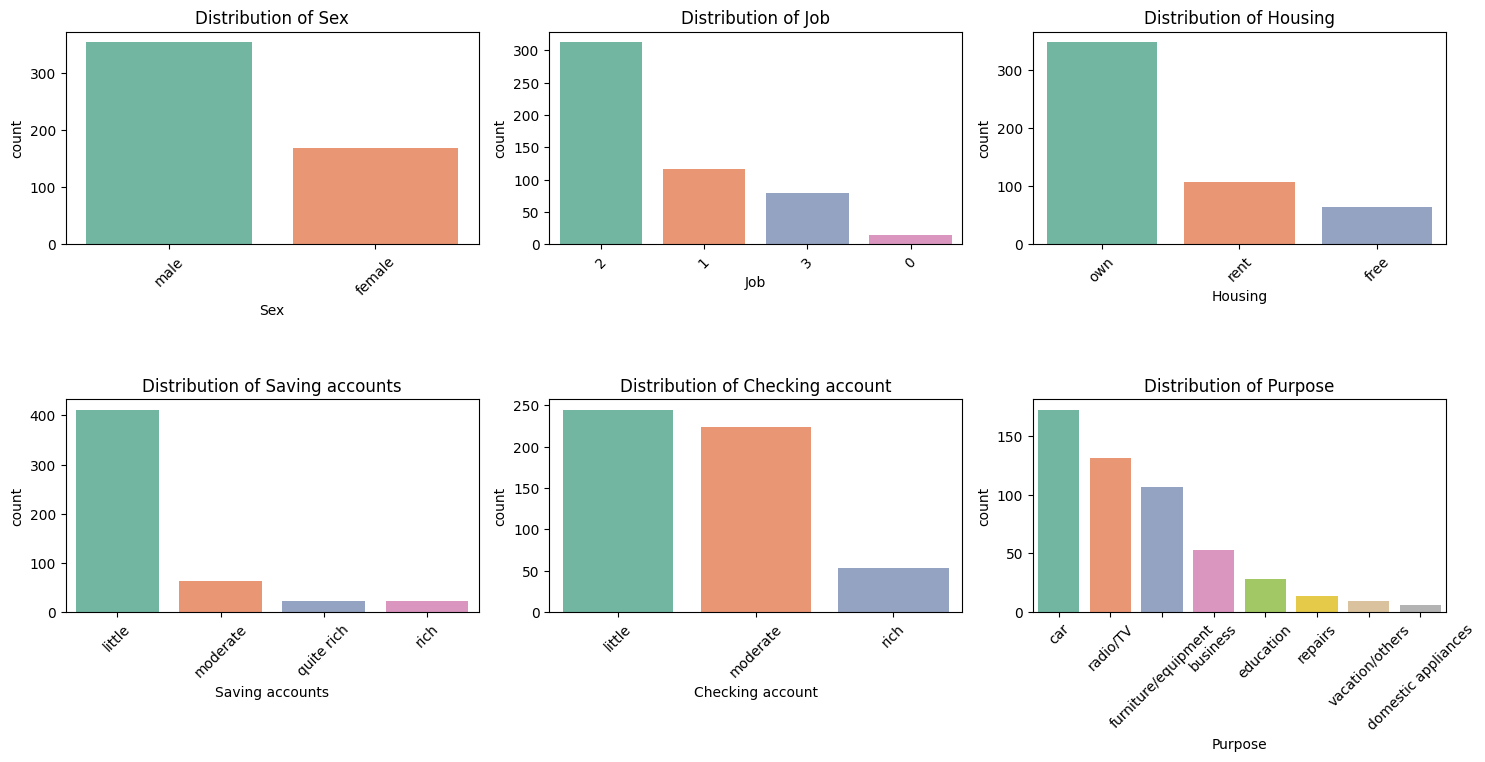

In [38]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols): 
    plt.subplot(3,3, i+1)
    sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

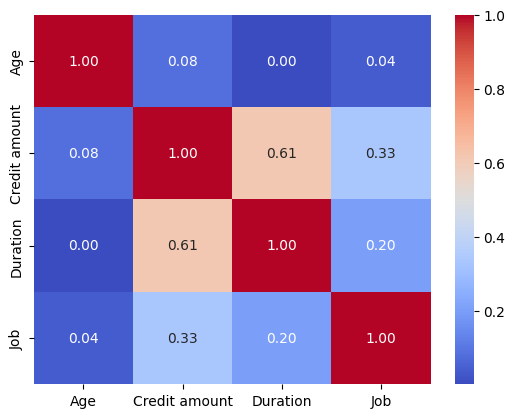

In [42]:
corr = df[["Age", "Credit amount", "Duration", "Job"]].corr() 

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f") 
plt.show() 

In [44]:
pd.pivot_table(df, values = "Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


<Axes: xlabel='Age', ylabel='Credit amount'>

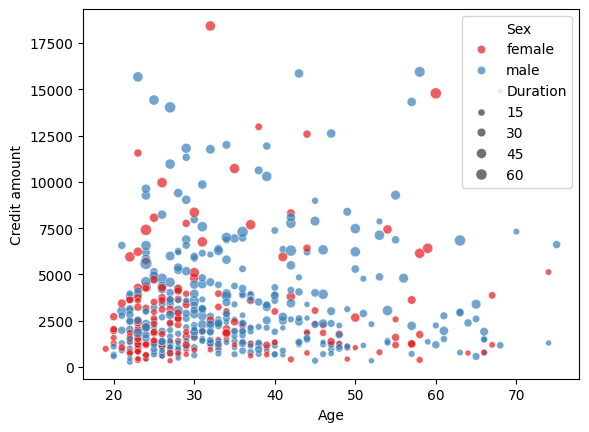

In [48]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size ="Duration", alpha=0.7, palette="Set1")

C:\Users\Startklar\AppData\Local\Temp\ipykernel_22484\2413435396.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y= "Credit amount", palette="Pastel1")


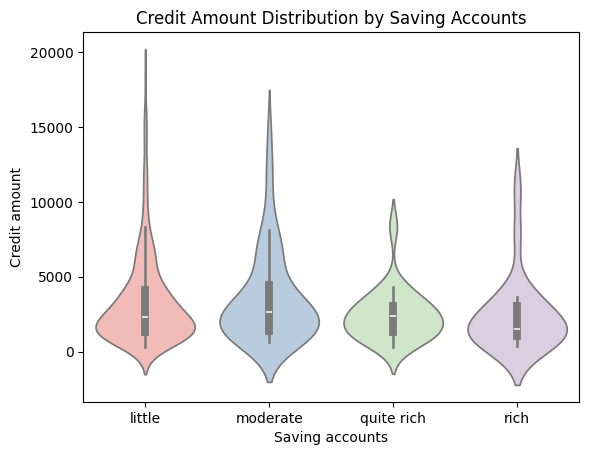

In [49]:
sns.violinplot(data=df, x="Saving accounts", y= "Credit amount", palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

In [50]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\Startklar\AppData\Local\Temp\ipykernel_22484\1871607098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
C:\Users\Startklar\AppData\Local\Temp\ipykernel_22484\1871607098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
C:\Users\Startklar\AppData\Local\Temp\ipykernel_22484\1871607098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")


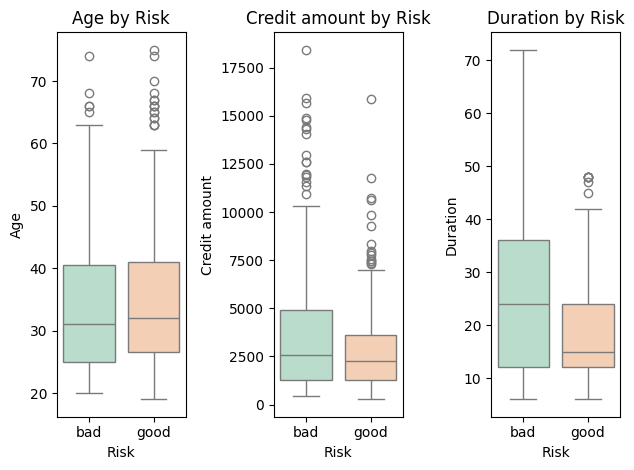

In [51]:
for i, col in enumerate(numerical_cols): 
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [53]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [55]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [57]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]
target = "Risk"

df_model = df[features + [target]].copy()
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [60]:
cat_cols = df_model.select_dtypes(include= "object").columns.drop("Risk")

le_dict = {}

for col in cat_cols: 
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le 

In [62]:
le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])

# 1 is good (low risk) and 0 is bad (high risk)

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [69]:
X = df_model.drop(target, axis = 1)
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 1)

In [70]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test): 
    grid = GridSearchCV(model, param_grid, cv=5, scoring= "accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    return best_model, acc, grid.best_params_

In [77]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")

dt_param_grid = {
    "max_depth" : [3,5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

print("Decision Tree Accuracy:", acc_dt)
print("Best Decision Tree parameters:", params_dt)


Decision Tree Accuracy: 0.580952380952381
Best Decision Tree parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
rf = RandomForestClassifier(random_state=1, class_weight= "balanced", n_jobs=-1)

rf_params_grid = {
 "n_estimators": [100,200], 
 "max_depth": [5, 7, 10, None], 
 "min_samples_split": [2,5,10], 
 "min_samples_leaf": [1,2,4]
}

best_rf, acc_rf, params_rf = train_model(rf, rf_params_grid, X_train, y_train, X_test, y_test)

print("Decision Tree Accuracy:", acc_rf)
print("Best Random Forest parameters:", params_rf)

Decision Tree Accuracy: 0.6190476190476191
Best Decision Tree parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [ ]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

et_params_grid = rf_params_grid

best_et, acc_et, params_et = train_model(et, et_params_grid, X_train, y_train, X_test, y_test)

print("Decision Tree Accuracy:", acc_et)
print("Best Extra Trees parameters:", params_et)

Decision Tree Accuracy: 0.6476190476190476
Best Decision Tree parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [80]:
xg = XGBClassifier(random_state=1, scale_pos_weight= (y_train == 0).sum() / (y_train==1).sum(), use_label_encode=False, eval_metric= "logloss")

xg_params_grid = {
    "n_estimators": [100, 200], 
    "max_depth": [3,5,7], 
    "learning_rate": [0.01, 0.1, 0.2], 
    "subsample": [0.7, 1], 
    "colsample_bytree": [0.7, 1]
}

best_xg, acc_xg, params_xg = train_model(xg, xg_params_grid, X_train, y_train, X_test, y_test)

print("XG Accuracy:", acc_xg)
print("Best XG parameters:", params_xg)

XG Accuracy: 0.6761904761904762
Best XG parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


c:\Users\Startklar\quant-risk\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:47:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encode" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
